<a href="https://colab.research.google.com/github/nadiduno/CienciaDeDados-BootCampFly/blob/main/desafiocondominionadi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Desafio - BootCamp | Ciência de Dados  | [Nadi Duno](https://www.linkedin.com/in/nadiduno/)

## 1 Importando as Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

## 2 Importando os dados

In [ ]:
url = 'https://raw.githubusercontent.com/nadiduno/CienciaDeDados-BootCampFly/refs/heads/main/Dados_Condominio.json'
dados = pd.read_json(url)
dados.head()

,dados_locacao
0,"{'apartamento': 'A101 (blocoAP)', 'datas_combi..."
1,"{'apartamento': 'A102 (blocoAP)', 'datas_combi..."
2,"{'apartamento': 'B201 (blocoAP)', 'datas_combi..."
3,"{'apartamento': 'B202 (blocoAP)', 'datas_combi..."
4,"{'apartamento': 'C301 (blocoAP)', 'datas_combi..."


In [ ]:
dados = pd.json_normalize(dados['dados_locacao'])
print('Dados carregados e normalizados com sucesso.')
dados.head()

Dados carregados e normalizados com sucesso.


,apartamento,datas_combinadas_pagamento,datas_de_pagamento,valor_aluguel
0,A101 (blocoAP),"[01/06/2022, 01/07/2022]","[05/06/2022, 03/07/2022]","[$ 1000,0 reais, $ 2500,0 reais]"
1,A102 (blocoAP),"[02/06/2022, 02/07/2022]","[02/06/2022, 06/07/2022]","[$ 1100,0 reais, $ 2600,0 reais]"
2,B201 (blocoAP),"[03/06/2022, 03/07/2022]","[07/06/2022, 03/07/2022]","[$ 1200,0 reais, $ 2700,0 reais]"
3,B202 (blocoAP),"[04/06/2022, 04/07/2022]","[07/06/2022, 05/07/2022]","[$ 1300,0 reais, $ 2800,0 reais]"
4,C301 (blocoAP),"[05/06/2022, 05/07/2022]","[10/06/2022, 09/07/2022]","[$ 1400,0 reais, $ 2900,0 reais]"


## 3 Conhecendo os dados

In [ ]:
print("Shape dos dados:", dados.shape)
print("\nInformações dos dados:")
print(dados.info())
print("\nTipos de dados:")
print(dados.dtypes)
print("\nInformações gerais:")
print(dados.info())
print("\nEstatísticas descritivas básicas incluye colunas qualitativas:")
print(dados.describe(include='object'))
print(f"Total de apartamentos: {len(dados)}")
print("\nColunas disponíveis:")
print(dados.columns.tolist())


Shape dos dados: (15, 4)

Informações dos dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   apartamento                 15 non-null     object
 1   datas_combinadas_pagamento  15 non-null     object
 2   datas_de_pagamento          15 non-null     object
 3   valor_aluguel               15 non-null     object
dtypes: object(4)
memory usage: 612.0+ bytes
None

Tipos de dados:
apartamento                   object
datas_combinadas_pagamento    object
datas_de_pagamento            object
valor_aluguel                 object
dtype: object

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   apartamento                 15 non-null     

## 4 Verificando dados nulos

In [ ]:
print("Valores nulos por coluna:")
print(dados.isnull().sum())
print(f"\nTotal de linhas com dados nulos: {dados.isnull().any(axis=1).sum()}")

# Decisão sobre dados nulos:
# Como os dados são de locação, podemos:
# 1. Remover linhas com dados nulos se forem poucas
# 2. Preencher com mediana/moda se forem muitas

if dados.isnull().sum().sum() > 0:
    # Vamos verificar a proporção de nulos
    null_percentage = (dados.isnull().sum() / len(dados)) * 100

    # Se menos de 5% nulos, removemos
    if null_percentage.max() < 5:
        dados = dados.dropna()
        print("Linhas com nulos removidas (menos de 5% nulos)")
    else:
        # Preenchemos com mediana para numéricos e moda para categóricos
        for col in dados.columns:
            if dados[col].dtype in ['int64', 'float64']:
                dados[col].fillna(dados[col].median(), inplace=True)
            else:
                dados[col].fillna(dados[col].mode()[0], inplace=True)
        print("Dados nulos preenchidos com mediana/moda")


Valores nulos por coluna:
apartamento                   0
datas_combinadas_pagamento    0
datas_de_pagamento            0
valor_aluguel                 0
dtype: int64

Total de linhas com dados nulos: 0


## Analise dos Aoutliers

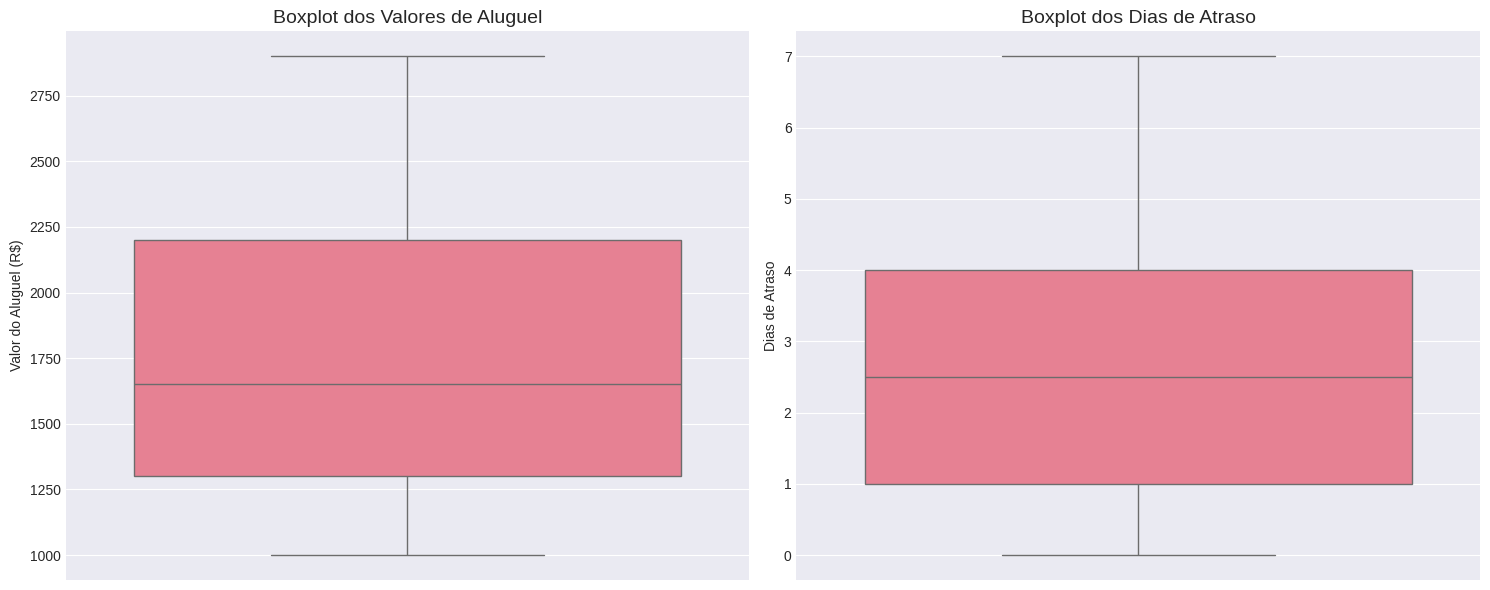

Estatísticas dos atrasos:
  Q1: 1.00 dias
  Q3: 4.00 dias
  IQR: 3.00 dias
  Limite superior: 8.50 dias
  Total de outliers detectados: 0
  Percentual de outliers: 0.00%

✅ DECISÃO: Manter outliers
Justificativa: Os outliers representam pagamentos com atrasos significativos,
que são informações valiosas para identificar apartamentos problemáticos.


In [ ]:
# Para detectar outliers, calculamos métricas por apartamento

# Função para extrair valor numérico de cada aluguel
def extrair_valores(lista_valores):
    valores = []
    for v in lista_valores:
        try:
            # Remove '$ ', ' reais' e converte vírgula para ponto
            num = float(v.replace('$ ', '').replace(' reais', '').replace(',', '.'))
            valores.append(num)
        except:
            valores.append(np.nan)
    return valores

# Calculando métricas por apartamento
metricas_apto = []
for idx, row in dados.iterrows():
    valores = extrair_valores(row['valor_aluguel'])
    if valores:
        metricas_apto.append({
            'apartamento': row['apartamento'],
            'min_aluguel': min(valores),
            'max_aluguel': max(valores),
            'media_aluguel': np.mean(valores),
            'std_aluguel': np.std(valores),
            'qtd_pagamentos': len(valores)
        })

df_metricas = pd.DataFrame(metricas_apto)

# Visualização de outliers - boxplot dos valores individuais
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot dos valores de aluguel (coletando todos os valores individuais)
todos_valores = []
for lista in dados['valor_aluguel']:
    todos_valores.extend(extrair_valores(lista))

sns.boxplot(y=todos_valores, ax=axes[0])
axes[0].set_title('Boxplot dos Valores de Aluguel', fontsize=14)
axes[0].set_ylabel('Valor do Aluguel (R$)')

# Boxplot dos atrasos (calculando dias de atraso para cada pagamento)
todos_atrasos = []
for idx, row in dados.iterrows():
    for data_comb, data_pag in zip(row['datas_combinadas_pagamento'], row['datas_de_pagamento']):
        try:
            d1 = datetime.strptime(data_comb, '%d/%m/%Y')
            d2 = datetime.strptime(data_pag, '%d/%m/%Y')
            atraso = (d2 - d1).days
            todos_atrasos.append(atraso)
        except:
            pass

sns.boxplot(y=todos_atrasos, ax=axes[1])
axes[1].set_title('Boxplot dos Dias de Atraso', fontsize=14)
axes[1].set_ylabel('Dias de Atraso')

plt.tight_layout()
plt.show()

# Identificando outliers usando IQR
Q1 = np.percentile(todos_atrasos, 25)
Q3 = np.percentile(todos_atrasos, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = [x for x in todos_atrasos if x < lower_bound or x > upper_bound]

print(f"Estatísticas dos atrasos:")
print(f"  Q1: {Q1:.2f} dias")
print(f"  Q3: {Q3:.2f} dias")
print(f"  IQR: {IQR:.2f} dias")
print(f"  Limite superior: {upper_bound:.2f} dias")
print(f"  Total de outliers detectados: {len(outliers)}")
print(f"  Percentual de outliers: {(len(outliers)/len(todos_atrasos))*100:.2f}%")

# Decisão: Manter outliers pois representam informações importantes
print("\n✅ DECISÃO: Manter outliers")
print("Justificativa: Os outliers representam pagamentos com atrasos significativos,")
print("que são informações valiosas para identificar apartamentos problemáticos.")

Decisão sobre outliers
Neste caso, como os valores parecem seguir uma progressão lógica (aumento de 100 em 100 + 1500),
podemos considerar que não há outliers significativos. Mas se houvesse:
- Manter: se fizer sentido no contexto do negócio
- Excluir: se for erro de digitação ou inconsistência
- Imputar com mediana: se for um valor discrepante mas plausível

 Como não há outliers evidentes, manteremos os dados originais

## Convertendo os dados

In [ ]:
dados.head()

,apartamento,datas_combinadas_pagamento,datas_de_pagamento,valor_aluguel
0,A101 (blocoAP),"[01/06/2022, 01/07/2022]","[05/06/2022, 03/07/2022]","[$ 1000,0 reais, $ 2500,0 reais]"
1,A102 (blocoAP),"[02/06/2022, 02/07/2022]","[02/06/2022, 06/07/2022]","[$ 1100,0 reais, $ 2600,0 reais]"
2,B201 (blocoAP),"[03/06/2022, 03/07/2022]","[07/06/2022, 03/07/2022]","[$ 1200,0 reais, $ 2700,0 reais]"
3,B202 (blocoAP),"[04/06/2022, 04/07/2022]","[07/06/2022, 05/07/2022]","[$ 1300,0 reais, $ 2800,0 reais]"
4,C301 (blocoAP),"[05/06/2022, 05/07/2022]","[10/06/2022, 09/07/2022]","[$ 1400,0 reais, $ 2900,0 reais]"


Data

In [ ]:
def converter_datas(lista_datas):
    """Converte lista de strings para datetime"""
    datas_convertidas = []
    for data_str in lista_datas:
        try:
            dt = datetime.strptime(data_str, '%d/%m/%Y')
            datas_convertidas.append(dt)
        except:
            datas_convertidas.append(None)
    return datas_convertidas

# Criando novas colunas com datas convertidas
dados['datas_comb_convertidas'] = dados['datas_combinadas_pagamento'].apply(converter_datas)
dados['datas_pag_convertidas'] = dados['datas_de_pagamento'].apply(converter_datas)

print("Datas convertidas com sucesso!")
print("\nExemplo de conversão:")
print(f"Original: {dados['datas_combinadas_pagamento'].iloc[0]}")
print(f"Convertida: {dados['datas_comb_convertidas'].iloc[0]}")

Datas convertidas com sucesso!

Exemplo de conversão:
Original: ['01/06/2022', '01/07/2022']
Convertida: [datetime.datetime(2022, 6, 1, 0, 0), datetime.datetime(2022, 7, 1, 0, 0)]


In [ ]:
dados.head()

,apartamento,datas_combinadas_pagamento,datas_de_pagamento,valor_aluguel,datas_comb_convertidas,datas_pag_convertidas
0,A101 (blocoAP),"[01/06/2022, 01/07/2022]","[05/06/2022, 03/07/2022]","[$ 1000,0 reais, $ 2500,0 reais]","[2022-06-01 00:00:00, 2022-07-01 00:00:00]","[2022-06-05 00:00:00, 2022-07-03 00:00:00]"
1,A102 (blocoAP),"[02/06/2022, 02/07/2022]","[02/06/2022, 06/07/2022]","[$ 1100,0 reais, $ 2600,0 reais]","[2022-06-02 00:00:00, 2022-07-02 00:00:00]","[2022-06-02 00:00:00, 2022-07-06 00:00:00]"
2,B201 (blocoAP),"[03/06/2022, 03/07/2022]","[07/06/2022, 03/07/2022]","[$ 1200,0 reais, $ 2700,0 reais]","[2022-06-03 00:00:00, 2022-07-03 00:00:00]","[2022-06-07 00:00:00, 2022-07-03 00:00:00]"
3,B202 (blocoAP),"[04/06/2022, 04/07/2022]","[07/06/2022, 05/07/2022]","[$ 1300,0 reais, $ 2800,0 reais]","[2022-06-04 00:00:00, 2022-07-04 00:00:00]","[2022-06-07 00:00:00, 2022-07-05 00:00:00]"
4,C301 (blocoAP),"[05/06/2022, 05/07/2022]","[10/06/2022, 09/07/2022]","[$ 1400,0 reais, $ 2900,0 reais]","[2022-06-05 00:00:00, 2022-07-05 00:00:00]","[2022-06-10 00:00:00, 2022-07-09 00:00:00]"


Valor de aluguel

In [ ]:
def converter_valores(lista_valores):
    """Converte lista de strings monetárias para float"""
    valores_num = []
    for v in lista_valores:
        try:
            # Remove '$ ', ' reais' e converte vírgula para ponto
            num = float(v.replace('$ ', '').replace(' reais', '').replace(',', '.'))
            valores_num.append(num)
        except:
            valores_num.append(np.nan)
    return valores_num

dados['valor_aluguel_numerico'] = dados['valor_aluguel'].apply(converter_valores)

print("Valores convertidos com sucesso!")
print("\nExemplo de conversão:")
print(f"Original: {dados['valor_aluguel'].iloc[0]}")
print(f"Convertido: {dados['valor_aluguel_numerico'].iloc[0]}")
print(f"Média geral: R$ {np.mean([v for sublist in dados['valor_aluguel_numerico'] for v in sublist if not np.isnan(v)]):.2f}")

Valores convertidos com sucesso!

Exemplo de conversão:
Original: ['$ 1000,0 reais', '$ 2500,0 reais']
Convertido: [1000.0, 2500.0]
Média geral: R$ 1786.67


In [ ]:
dados.head ()

,apartamento,datas_combinadas_pagamento,datas_de_pagamento,valor_aluguel,datas_comb_convertidas,datas_pag_convertidas,valor_aluguel_numerico
0,A101 (blocoAP),"[01/06/2022, 01/07/2022]","[05/06/2022, 03/07/2022]","[$ 1000,0 reais, $ 2500,0 reais]","[2022-06-01 00:00:00, 2022-07-01 00:00:00]","[2022-06-05 00:00:00, 2022-07-03 00:00:00]","[1000.0, 2500.0]"
1,A102 (blocoAP),"[02/06/2022, 02/07/2022]","[02/06/2022, 06/07/2022]","[$ 1100,0 reais, $ 2600,0 reais]","[2022-06-02 00:00:00, 2022-07-02 00:00:00]","[2022-06-02 00:00:00, 2022-07-06 00:00:00]","[1100.0, 2600.0]"
2,B201 (blocoAP),"[03/06/2022, 03/07/2022]","[07/06/2022, 03/07/2022]","[$ 1200,0 reais, $ 2700,0 reais]","[2022-06-03 00:00:00, 2022-07-03 00:00:00]","[2022-06-07 00:00:00, 2022-07-03 00:00:00]","[1200.0, 2700.0]"
3,B202 (blocoAP),"[04/06/2022, 04/07/2022]","[07/06/2022, 05/07/2022]","[$ 1300,0 reais, $ 2800,0 reais]","[2022-06-04 00:00:00, 2022-07-04 00:00:00]","[2022-06-07 00:00:00, 2022-07-05 00:00:00]","[1300.0, 2800.0]"
4,C301 (blocoAP),"[05/06/2022, 05/07/2022]","[10/06/2022, 09/07/2022]","[$ 1400,0 reais, $ 2900,0 reais]","[2022-06-05 00:00:00, 2022-07-05 00:00:00]","[2022-06-10 00:00:00, 2022-07-09 00:00:00]","[1400.0, 2900.0]"


## Analisar o atraso no pagamento de aluguéis no condomínio de alguns moradores

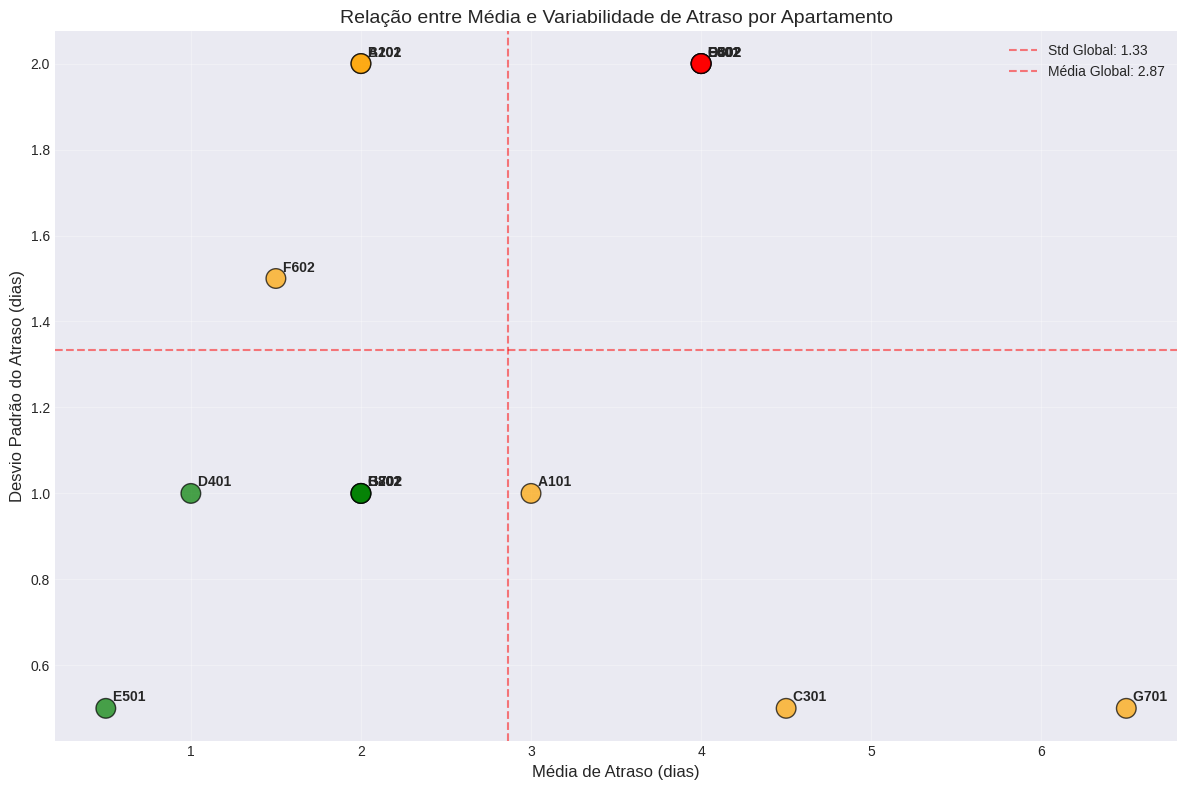

Média global de atraso: 2.87 dias
Desvio padrão global: 1.33 dias

Apartamentos com alto risco:
       apartamento  media_atraso  std_atraso  max_atraso
5   C302 (blocoAP)          4.00        2.00           6
7   D402 (blocoAP)          4.00        2.00           6
9   E502 (blocoAP)          4.00        2.00           6
10  F601 (blocoAP)          4.00        2.00           6


In [ ]:
# Calculando métricas de atraso

def calcular_atrasos(row):
    """Calcula atrasos para um apartamento"""
    atrasos = []
    for data_comb, data_pag in zip(row['datas_comb_convertidas'], row['datas_pag_convertidas']):
        if data_comb and data_pag:
            atraso = (data_pag - data_comb).days
            atrasos.append(atraso)
    return atrasos

dados['dias_atraso'] = dados.apply(calcular_atrasos, axis=1)

# Calculando métricas por apartamento
dados['media_atraso'] = dados['dias_atraso'].apply(lambda x: np.mean(x) if x else 0)
dados['std_atraso'] = dados['dias_atraso'].apply(lambda x: np.std(x) if len(x) > 1 else 0)
dados['max_atraso'] = dados['dias_atraso'].apply(lambda x: max(x) if x else 0)

# Identificando apartamentos com alta média e variabilidade (Desvio Padrão)
media_global = np.mean([m for m in dados['media_atraso'] if m > 0])
std_global = np.mean([s for s in dados['std_atraso'] if s > 0])

dados['risco'] = dados.apply(
    lambda row: 'Alto Risco' if (row['media_atraso'] > media_global and row['std_atraso'] > std_global)
    else 'Médio Risco' if (row['media_atraso'] > media_global or row['std_atraso'] > std_global)
    else 'Baixo Risco',
    axis=1
)

# Gráfico de dispersão (melhor para mostrar relação média vs variabilidade)
fig, ax = plt.subplots(figsize=(12, 8))

# Criando cores baseadas no risco
cores = {'Alto Risco': 'red', 'Médio Risco': 'orange', 'Baixo Risco': 'green'}
scatter = ax.scatter(
    dados['media_atraso'],
    dados['std_atraso'],
    c=[cores[risco] for risco in dados['risco']],
    s=200,
    alpha=0.7,
    edgecolors='black'
)

# Anotando os apartamentos
for idx, row in dados.iterrows():
    ax.annotate(
        row['apartamento'].split('(')[0],
        (row['media_atraso'], row['std_atraso']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

# Linhas de referência
ax.axhline(y=std_global, color='red', linestyle='--', alpha=0.5, label=f'Std Global: {std_global:.2f}')
ax.axvline(x=media_global, color='red', linestyle='--', alpha=0.5, label=f'Média Global: {media_global:.2f}')

ax.set_xlabel('Média de Atraso (dias)', fontsize=12)
ax.set_ylabel('Desvio Padrão do Atraso (dias)', fontsize=12)
ax.set_title('Relação entre Média e Variabilidade de Atraso por Apartamento', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Média global de atraso: {media_global:.2f} dias")
print(f"Desvio padrão global: {std_global:.2f} dias")
print("\nApartamentos com alto risco:")
print(dados[dados['risco'] == 'Alto Risco'][['apartamento', 'media_atraso', 'std_atraso', 'max_atraso']])

In [ ]:
dados.head(7)

,apartamento,datas_combinadas_pagamento,datas_de_pagamento,valor_aluguel,datas_comb_convertidas,datas_pag_convertidas,valor_aluguel_numerico,dias_atraso,media_atraso,std_atraso,max_atraso,risco
0,A101 (blocoAP),"[01/06/2022, 01/07/2022]","[05/06/2022, 03/07/2022]","[$ 1000,0 reais, $ 2500,0 reais]","[2022-06-01 00:00:00, 2022-07-01 00:00:00]","[2022-06-05 00:00:00, 2022-07-03 00:00:00]","[1000.0, 2500.0]","[4, 2]",3.00,1.00,4,Médio Risco
1,A102 (blocoAP),"[02/06/2022, 02/07/2022]","[02/06/2022, 06/07/2022]","[$ 1100,0 reais, $ 2600,0 reais]","[2022-06-02 00:00:00, 2022-07-02 00:00:00]","[2022-06-02 00:00:00, 2022-07-06 00:00:00]","[1100.0, 2600.0]","[0, 4]",2.00,2.00,4,Médio Risco
2,B201 (blocoAP),"[03/06/2022, 03/07/2022]","[07/06/2022, 03/07/2022]","[$ 1200,0 reais, $ 2700,0 reais]","[2022-06-03 00:00:00, 2022-07-03 00:00:00]","[2022-06-07 00:00:00, 2022-07-03 00:00:00]","[1200.0, 2700.0]","[4, 0]",2.00,2.00,4,Médio Risco
3,B202 (blocoAP),"[04/06/2022, 04/07/2022]","[07/06/2022, 05/07/2022]","[$ 1300,0 reais, $ 2800,0 reais]","[2022-06-04 00:00:00, 2022-07-04 00:00:00]","[2022-06-07 00:00:00, 2022-07-05 00:00:00]","[1300.0, 2800.0]","[3, 1]",2.00,1.00,3,Baixo Risco
4,C301 (blocoAP),"[05/06/2022, 05/07/2022]","[10/06/2022, 09/07/2022]","[$ 1400,0 reais, $ 2900,0 reais]","[2022-06-05 00:00:00, 2022-07-05 00:00:00]","[2022-06-10 00:00:00, 2022-07-09 00:00:00]","[1400.0, 2900.0]","[5, 4]",4.50,0.50,5,Médio Risco
5,C302 (blocoAP),"[06/06/2022, 06/07/2022]","[08/06/2022, 12/07/2022]","[$ 1500,0 reais, $ 1200,0 reais]","[2022-06-06 00:00:00, 2022-07-06 00:00:00]","[2022-06-08 00:00:00, 2022-07-12 00:00:00]","[1500.0, 1200.0]","[2, 6]",4.00,2.00,6,Alto Risco
6,D401 (blocoAP),"[07/06/2022, 07/07/2022]","[07/06/2022, 09/07/2022]","[$ 1600,0 reais, $ 1300,0 reais]","[2022-06-07 00:00:00, 2022-07-07 00:00:00]","[2022-06-07 00:00:00, 2022-07-09 00:00:00]","[1600.0, 1300.0]","[0, 2]",1.00,1.00,2,Baixo Risco


## Apartamentos com maoir média de atasos

TOP 5 APARTAMENTOS COM MAIOR MÉDIA DE ATRASO:

G701 :
  Média de atraso: 6.50 dias
  Desvio padrão: 0.50 dias
  Máximo atraso: 7 dias
  Todos os atrasos: [6, 7]

C301 :
  Média de atraso: 4.50 dias
  Desvio padrão: 0.50 dias
  Máximo atraso: 5 dias
  Todos os atrasos: [5, 4]

C302 :
  Média de atraso: 4.00 dias
  Desvio padrão: 2.00 dias
  Máximo atraso: 6 dias
  Todos os atrasos: [2, 6]

D402 :
  Média de atraso: 4.00 dias
  Desvio padrão: 2.00 dias
  Máximo atraso: 6 dias
  Todos os atrasos: [2, 6]

E502 :
  Média de atraso: 4.00 dias
  Desvio padrão: 2.00 dias
  Máximo atraso: 6 dias
  Todos os atrasos: [6, 2]


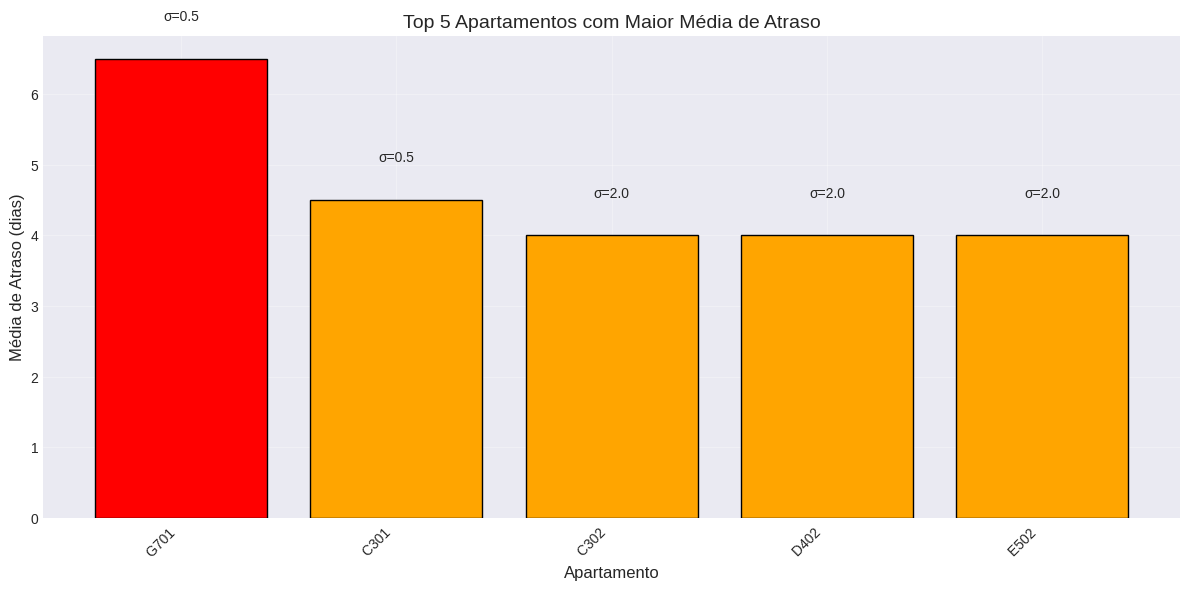

In [ ]:
top_aptos = dados.nlargest(5, 'media_atraso')

print("TOP 5 APARTAMENTOS COM MAIOR MÉDIA DE ATRASO:")
print("=" * 50)
for idx, row in top_aptos.iterrows():
    print(f"\n{row['apartamento'].split('(')[0]}:")
    print(f"  Média de atraso: {row['media_atraso']:.2f} dias")
    print(f"  Desvio padrão: {row['std_atraso']:.2f} dias")
    print(f"  Máximo atraso: {row['max_atraso']} dias")
    print(f"  Todos os atrasos: {row['dias_atraso']}")

# Gráfico de barras
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    [apto.split('(')[0] for apto in top_aptos['apartamento']],
    top_aptos['media_atraso'],
    color=['red' if i==0 else 'orange' for i in range(len(top_aptos))],
    edgecolor='black'
)

# Adicionando valores nas barras
for bar, std in zip(bars, top_aptos['std_atraso']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'σ={std:.1f}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Apartamento', fontsize=12)
ax.set_ylabel('Média de Atraso (dias)', fontsize=12)
ax.set_title('Top 5 Apartamentos com Maior Média de Atraso', fontsize=14)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Apartamentos críticos (alto atraso + alta variabil

APARTAMENTOS CRÍTICOS - EXIGEM MAIOR ATENÇÃO
Total de apartamentos críticos: 4

Critérios utilizados:
  • Média de atraso > 2.87 dias (média global)
  • Desvio padrão > 1.33 dias (variabilidade global)

DETALHES DOS APARTAMENTOS CRÍTICOS:
------------------------------------------------------------

 C302 :
  Média de atraso: 4.00 dias
  Variabilidade: 2.00 dias
  Máximo atraso: 6 dias
  Histórico de atrasos: [2, 6]
  Nível de risco: Alto Risco

 D402 :
  Média de atraso: 4.00 dias
  Variabilidade: 2.00 dias
  Máximo atraso: 6 dias
  Histórico de atrasos: [2, 6]
  Nível de risco: Alto Risco

 E502 :
  Média de atraso: 4.00 dias
  Variabilidade: 2.00 dias
  Máximo atraso: 6 dias
  Histórico de atrasos: [6, 2]
  Nível de risco: Alto Risco

 F601 :
  Média de atraso: 4.00 dias
  Variabilidade: 2.00 dias
  Máximo atraso: 6 dias
  Histórico de atrasos: [6, 2]
  Nível de risco: Alto Risco


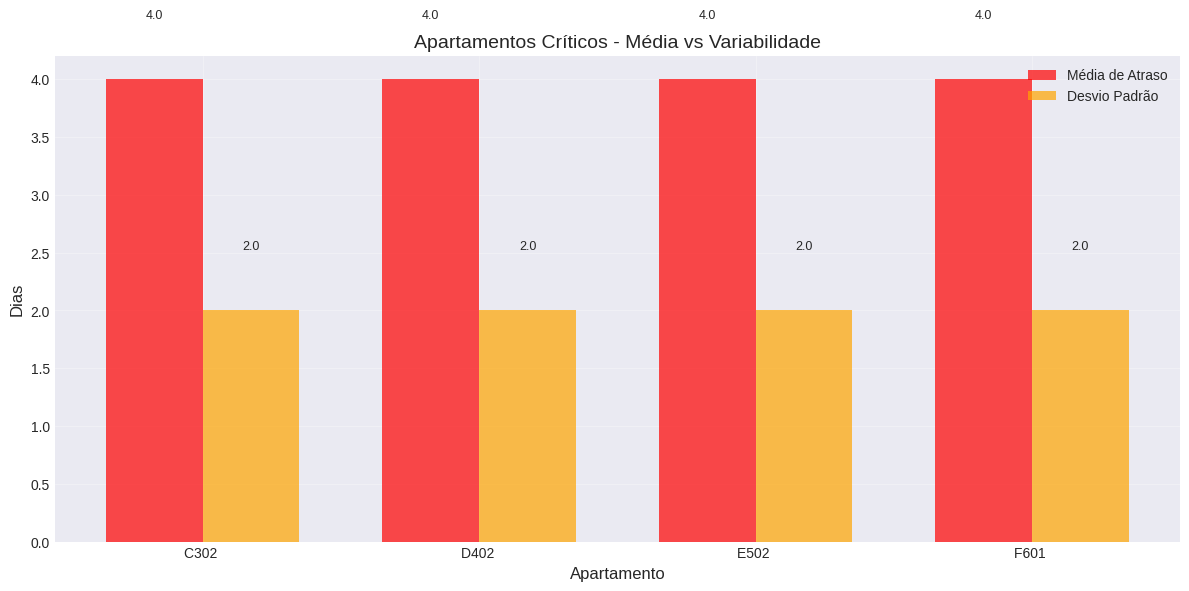

In [ ]:
criticos = dados[(dados['media_atraso'] > media_global) & (dados['std_atraso'] > std_global)]

print("=" * 60)
print("APARTAMENTOS CRÍTICOS - EXIGEM MAIOR ATENÇÃO")
print("=" * 60)
print(f"Total de apartamentos críticos: {len(criticos)}")
print(f"\nCritérios utilizados:")
print(f"  • Média de atraso > {media_global:.2f} dias (média global)")
print(f"  • Desvio padrão > {std_global:.2f} dias (variabilidade global)")

print("\nDETALHES DOS APARTAMENTOS CRÍTICOS:")
print("-" * 60)
for idx, row in criticos.iterrows():
    print(f"\n {row['apartamento'].split('(')[0]}:")
    print(f"  Média de atraso: {row['media_atraso']:.2f} dias")
    print(f"  Variabilidade: {row['std_atraso']:.2f} dias")
    print(f"  Máximo atraso: {row['max_atraso']} dias")
    print(f"  Histórico de atrasos: {row['dias_atraso']}")
    print(f"  Nível de risco: {row['risco']}")

# Gráfico específico para críticos
if len(criticos) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(criticos))
    width = 0.35

    bars1 = ax.bar(x - width/2, criticos['media_atraso'], width, label='Média de Atraso', color='red', alpha=0.7)
    bars2 = ax.bar(x + width/2, criticos['std_atraso'], width, label='Desvio Padrão', color='orange', alpha=0.7)

    ax.set_xlabel('Apartamento', fontsize=12)
    ax.set_ylabel('Dias', fontsize=12)
    ax.set_title('Apartamentos Críticos - Média vs Variabilidade', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([a.split('(')[0] for a in criticos['apartamento']])
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Adicionando valores
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

##  Cálculos extras importantes

Análises por Bloco


1. ESTATÍSTICAS POR BLOCO:
       media_atraso  std_atraso  max_atraso
bloco                                      
A              2.50        1.50           4
B              2.00        1.50           4
C              4.25        1.25           6
D              2.50        1.50           6
E              2.25        1.25           6
F              2.75        1.75           6
G              4.25        0.75           7
H              2.00        1.00           3


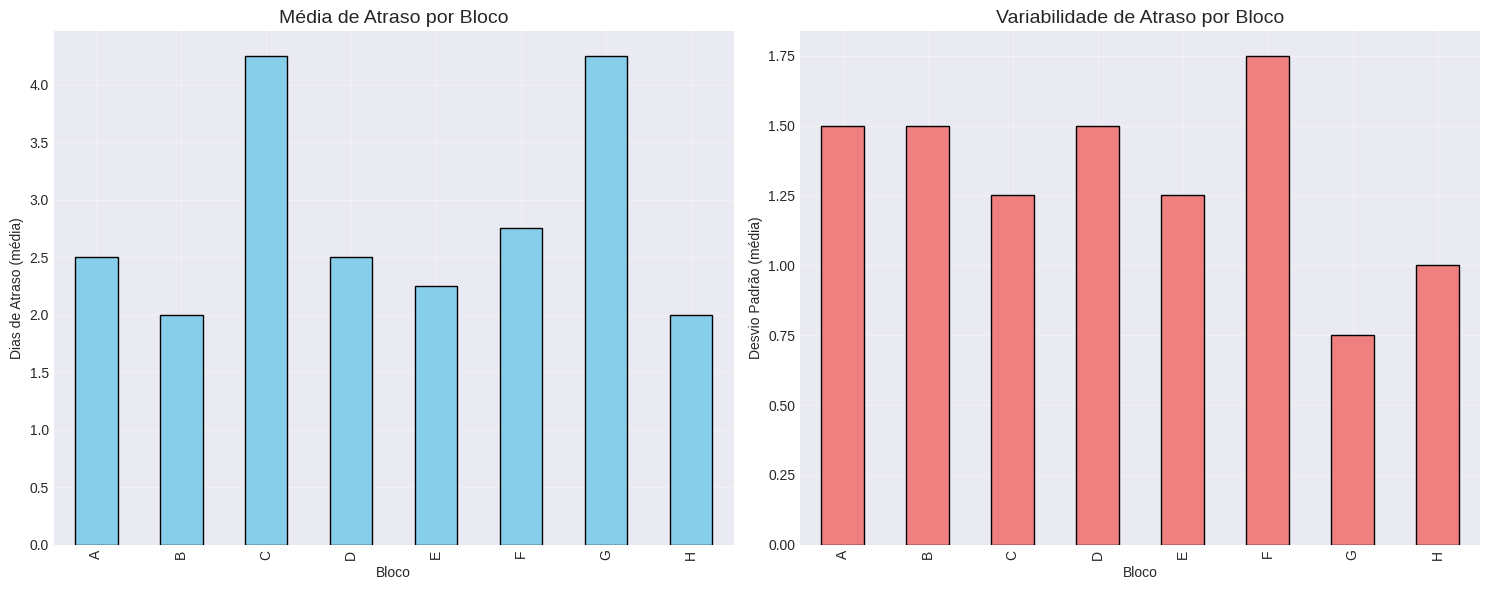

In [ ]:
dados['bloco'] = dados['apartamento'].str.extract(r'([A-Z])')
estatisticas_bloco = dados.groupby('bloco').agg({
    'media_atraso': 'mean',
    'std_atraso': 'mean',
    'max_atraso': 'max'
}).round(2)

print("\n1. ESTATÍSTICAS POR BLOCO:")
print(estatisticas_bloco)

# Gráfico por bloco
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

estatisticas_bloco['media_atraso'].plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Média de Atraso por Bloco', fontsize=14)
ax1.set_xlabel('Bloco')
ax1.set_ylabel('Dias de Atraso (média)')
ax1.grid(True, alpha=0.3)

estatisticas_bloco['std_atraso'].plot(kind='bar', ax=ax2, color='lightcoral', edgecolor='black')
ax2.set_title('Variabilidade de Atraso por Bloco', fontsize=14)
ax2.set_xlabel('Bloco')
ax2.set_ylabel('Desvio Padrão (média)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



2. Eficiência de Pagamento

In [ ]:
def calcular_eficiencia(row):
    total = len(row['dias_atraso'])
    em_dia = sum(1 for a in row['dias_atraso'] if a <= 0)
    return (em_dia / total * 100) if total > 0 else 0

dados['eficiencia'] = dados.apply(calcular_eficiencia, axis=1)

print("\n2. EFICIÊNCIA DE PAGAMENTO:")
print(f"  Média geral: {dados['eficiencia'].mean():.1f}%")
print(f"  Melhor apartamento: {dados.loc[dados['eficiencia'].idxmax(), 'apartamento'].split('(')[0]} ({dados['eficiencia'].max():.1f}%)")
print(f"  Pior apartamento: {dados.loc[dados['eficiencia'].idxmin(), 'apartamento'].split('(')[0]} ({dados['eficiencia'].min():.1f}%)")



2. EFICIÊNCIA DE PAGAMENTO:
  Média geral: 16.7%
  Melhor apartamento: A102  (50.0%)
  Pior apartamento: A101  (0.0%)


3. Correlações

In [ ]:
valores_flat = [v for sublist in dados['valor_aluguel_numerico'] for v in sublist if not np.isnan(v)]
atrasos_flat = [a for sublist in dados['dias_atraso'] for a in sublist]

if len(valores_flat) == len(atrasos_flat):
    correlacao = np.corrcoef(valores_flat, atrasos_flat)[0, 1]
    print(f"\n3. CORRELAÇÃO VALOR × ATRASO: {correlacao:.3f}")
    if abs(correlacao) < 0.3:
        print("  → Correlação FRACA: valor do aluguel não influencia atraso")
    elif abs(correlacao) < 0.7:
        print("  → Correlação MODERADA: há alguma relação entre valor e atraso")
    else:
        print("  → Correlação FORTE: valores mais altos tendem a ter mais atrasos")



3. CORRELAÇÃO VALOR × ATRASO: -0.090
  → Correlação FRACA: valor do aluguel não influencia atraso


Praticamente SEM relação!

Isso significa:
✅ O valor do aluguel NÃO influencia se a pessoa vai atrasar ou não
✅ Tanto apartamentos baratos quanto caros atrasam igualmente
✅ O problema de atraso é comportamental, não financeiro

4. Score de Risco (Decisão do Cientista de Dados)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Criando features para o score
features = dados[['media_atraso', 'std_atraso', 'max_atraso']].copy()
scaler = MinMaxScaler()
features_normalized = scaler.fit_transform(features)

# Score ponderado: 40% média + 35% variabilidade + 25% máximo
dados['risk_score'] = (0.4 * features_normalized[:, 0] +
                       0.35 * features_normalized[:, 1] +
                       0.25 * features_normalized[:, 2]) * 100

print("\n4. SCORE DE RISCO (0-100):")
print(f"  Mínimo: {dados['risk_score'].min():.2f}")
print(f"  Médio: {dados['risk_score'].mean():.2f}")
print(f"  Máximo: {dados['risk_score'].max():.2f}")

print("\n  Top 5 apartamentos com maior risco:")
top_risco = dados.nlargest(5, 'risk_score')[['apartamento', 'media_atraso', 'std_atraso', 'risk_score']]
for idx, row in top_risco.iterrows():
    print(f"    • {row['apartamento'].split('(')[0]}: Score {row['risk_score']:.1f} | Média: {row['media_atraso']:.1f}d | Std: {row['std_atraso']:.1f}d")



4. SCORE DE RISCO (0-100):
  Mínimo: 0.00
  Médio: 48.56
  Máximo: 79.17

  Top 5 apartamentos com maior risco:
    • C302 : Score 79.2 | Média: 4.0d | Std: 2.0d
    • D402 : Score 79.2 | Média: 4.0d | Std: 2.0d
    • E502 : Score 79.2 | Média: 4.0d | Std: 2.0d
    • F601 : Score 79.2 | Média: 4.0d | Std: 2.0d
    • G701 : Score 65.0 | Média: 6.5d | Std: 0.5d


5. Recomendações (Decisões Estratégicas)

In [ ]:
print("\n5. RECOMENDAÇÕES ESTRATÉGICAS:")
print("=" * 60)

print("\n Ações Imediatas (Apartamentos Críticos):")
for apto in criticos['apartamento']:
    print(f"  → {apto.split('(')[0]}: Implementar seguimento semanal")

print("\n Monitoramento Contínuo:")
print("  → Criar dashboard com métricas de atraso por apartamento")
print("  → Revisar score de risco mensalmente")
print("  → Analisar tendências sazonais de pagamento")

print("\n Políticas de Incentivo:")
print("  → Oferecer desconto para pagamento em dia (5% de desconto)")
print("  → Implementar multa progressiva para atrasos recorrentes")
print("  → Criar programa de fidelidade para bons pagadores")

print("\n Análises Futuras:")
print("  → Investigar causas dos atrasos (entrevistas com moradores)")
print("  → Analisar se há relação entre reformas/ocupação e atrasos")
print("  → Prever atrasos futuros com modelos de machine learning")



5. RECOMENDAÇÕES ESTRATÉGICAS:

 Ações Imediatas (Apartamentos Críticos):
  → C302 : Implementar seguimento semanal
  → D402 : Implementar seguimento semanal
  → E502 : Implementar seguimento semanal
  → F601 : Implementar seguimento semanal

 Monitoramento Contínuo:
  → Criar dashboard com métricas de atraso por apartamento
  → Revisar score de risco mensalmente
  → Analisar tendências sazonais de pagamento

 Políticas de Incentivo:
  → Oferecer desconto para pagamento em dia (5% de desconto)
  → Implementar multa progressiva para atrasos recorrentes
  → Criar programa de fidelidade para bons pagadores

 Análises Futuras:
  → Investigar causas dos atrasos (entrevistas com moradores)
  → Analisar se há relação entre reformas/ocupação e atrasos
  → Prever atrasos futuros com modelos de machine learning


6. Métricas Resumo

In [ ]:
print("\n6. RESUMO EXECUTIVO:")
print("=" * 60)
print(f"Total de apartamentos: {len(dados)}")
print(f"Total de pagamentos analisados: {sum(len(row['dias_atraso']) for _, row in dados.iterrows())}")
print(f"Atraso médio geral: {np.mean(atrasos_flat):.2f} dias")
print(f"Apartamentos críticos: {len(criticos)} ({len(criticos)/len(dados)*100:.1f}% do total)")
print(f"Eficiência média de pagamento: {dados['eficiencia'].mean():.1f}%")
print(f"Risco médio geral: {dados['risk_score'].mean():.1f}/100")

print("\n" + "=" * 60)
print("ANÁLISE CONCLUÍDA COM SUCESSO!")
print("=" * 60)


6. RESUMO EXECUTIVO:
Total de apartamentos: 15
Total de pagamentos analisados: 30
Atraso médio geral: 2.87 dias
Apartamentos críticos: 4 (26.7% do total)
Eficiência média de pagamento: 16.7%
Risco médio geral: 48.6/100

ANÁLISE CONCLUÍDA COM SUCESSO!
